# Mini Project 4

In this final mini project, I explore the impact of a non-constant $\sigma$ on the distribution of profits of hedging. 

In [21]:
#Package Import
import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import shapiro
import scipy.stats as stats
from scipy.optimize import brentq
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import quad
sns.set_style('darkgrid')
from scipy.optimize import minimize
from joblib import Parallel, delayed
from scipy.stats import rv_discrete
from statsmodels.stats.diagnostic import acorr_ljungbox


%run functions.py

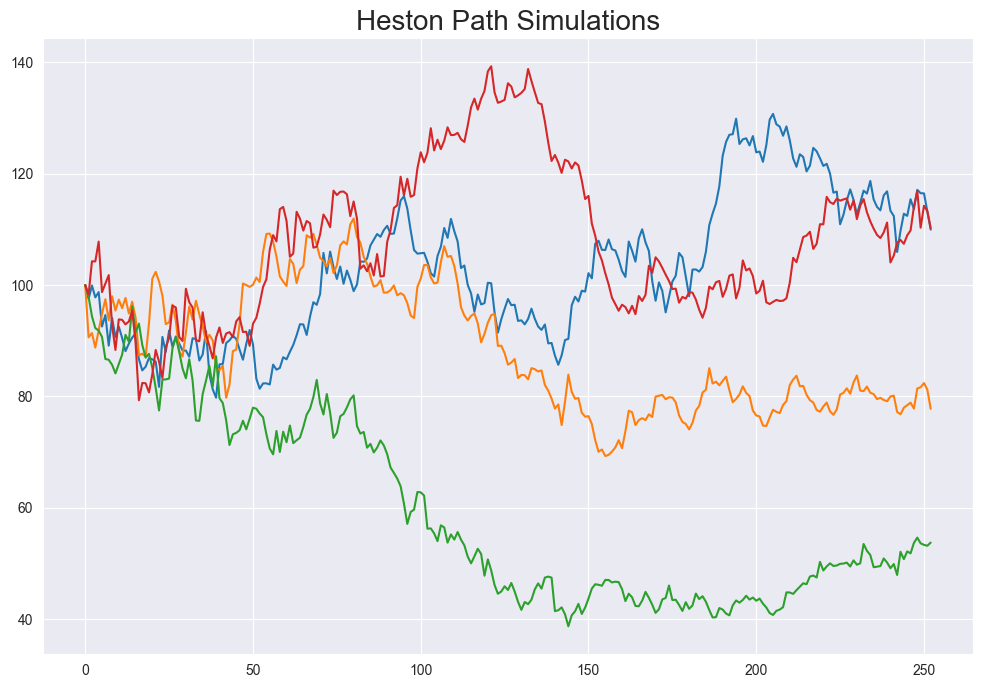

In [22]:
#Generation of custom stock paths following Geometeric Brownian motion, but log-returns do not have constant volatility.
 #Custom sigma that is not constant
#paramters: 
S0 = 100
v0 = .22*2
t = 1
r = 0.035 #risk-free interest rate
mu = 0.034
n_steps = 252
n_sims = 4
kappa = 2.4
theta = .3**2
xi =  .43 
rho = -0.6

heston_paths = heston_path_sim(S0, v0, r, t, n_steps, kappa, theta, xi, rho, n_sims, mu)
n_paths = heston_paths

plt.figure(figsize = (12,8))
for path in heston_paths:
    plt.plot(path)
    
    
plt.title('Heston Path Simulations', size = 20)

plt.show()

C:\Users\anshu\AppData\Local\Temp\ipykernel_37368\1987160753.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(ticker, period = '15y', interval = '1d')
[*********************100%***********************]  1 of 1 completed


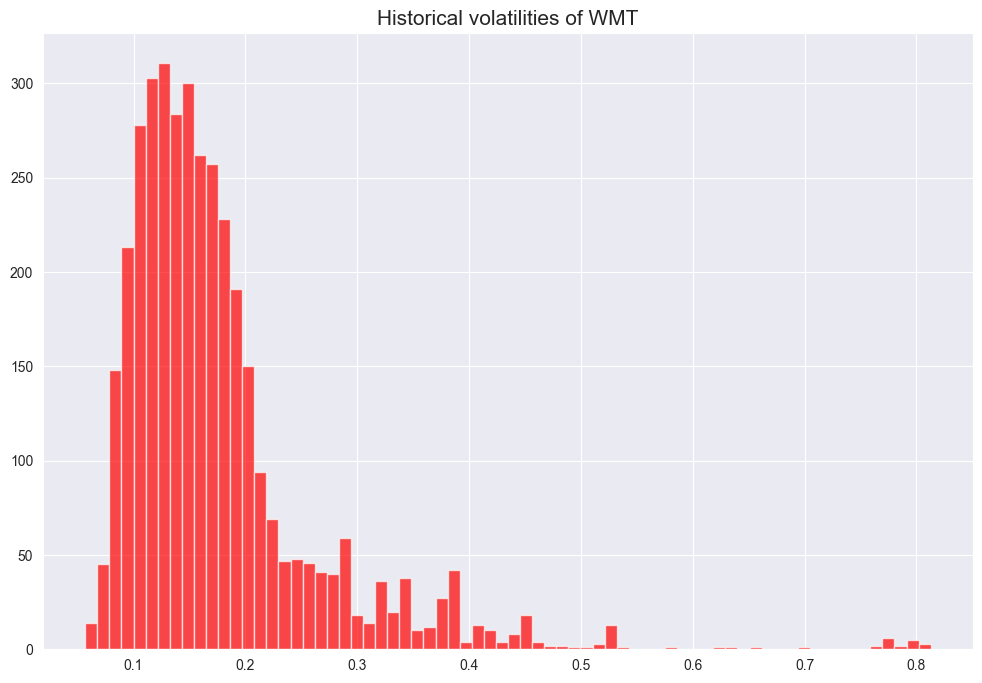

Ticker           WMT
Date                
2010-07-06       NaN
2010-07-07       NaN
2010-07-08       NaN
2010-07-09       NaN
2010-07-12       NaN
...              ...
2025-06-27  0.156354
2025-06-30  0.157276
2025-07-01  0.146897
2025-07-02  0.142887
2025-07-03  0.145693

[3773 rows x 1 columns]


In [23]:
#Real World Distribution of Historical volatilites of a stock

tickers = ['WMT']

for ticker in tickers:

    stock = yf.download(ticker, period = '15y', interval = '1d')

    #Historical volatilities of stock measured over 21 day trading days
    historical_vols = np.log(stock['Close']/stock['Close'].shift(1)).rolling(window = 21).std()*np.sqrt(252)

    plt.figure(figsize = (12, 8))
    plt.hist(historical_vols, bins = 70, color = 'red', alpha = .7)
    plt.title(f'Historical volatilities of {ticker}', size = 15)
    plt.show()
    print(historical_vols)

In [24]:
def stock_path_custom_sigma(S0, t, r, mu, n_paths, n_steps):
    '''
    Generation of custom stock paths following Geometeric Brownian motion,
    but log-returns do not have constant volatility.
    
    Each step of the log-returns, there is a 
    1) 50% the volatility is .2
    2) 30% chance the volatility is .3
    3) 20% chance the volatility is .45
    
    Inputs:
    S0 (float): initial stock value
    t (float): time interval of stock path movements in years
    r (float): risk-free interest rate
    mu (float): drift of log-returns
    n_paths (int): number of stock paths
    n_steps (float): number of steps in each stock path
    
    Returns:
    
    Simuatled stock paths
    '''
    
    #Noise in volatility
    noise = np.random.normal(0,1,size = (n_paths, n_steps))
    
    #Custom sigma that is not constant
    sigma = np.random.choice([.2,.3,.45], p = [.5, .3, .2], size = (n_paths, n_steps))
    
    #Time increment between each step
    dt = t/n_steps
    
    #log-returns between each step
    increments = (mu + r - .5*sigma**2)*dt + sigma*np.sqrt(dt)*noise
    
    #Cumulative log-returns at each step
    log_returns = np.cumsum(increments, axis = 1)
    
    
    #paths
    paths = S0*np.exp(log_returns)
    
    
    #Adjoint initial value S0 at start of each simulated path
    paths = np.insert(paths, 0, S0, axis = 1)
    
    
    return paths
    

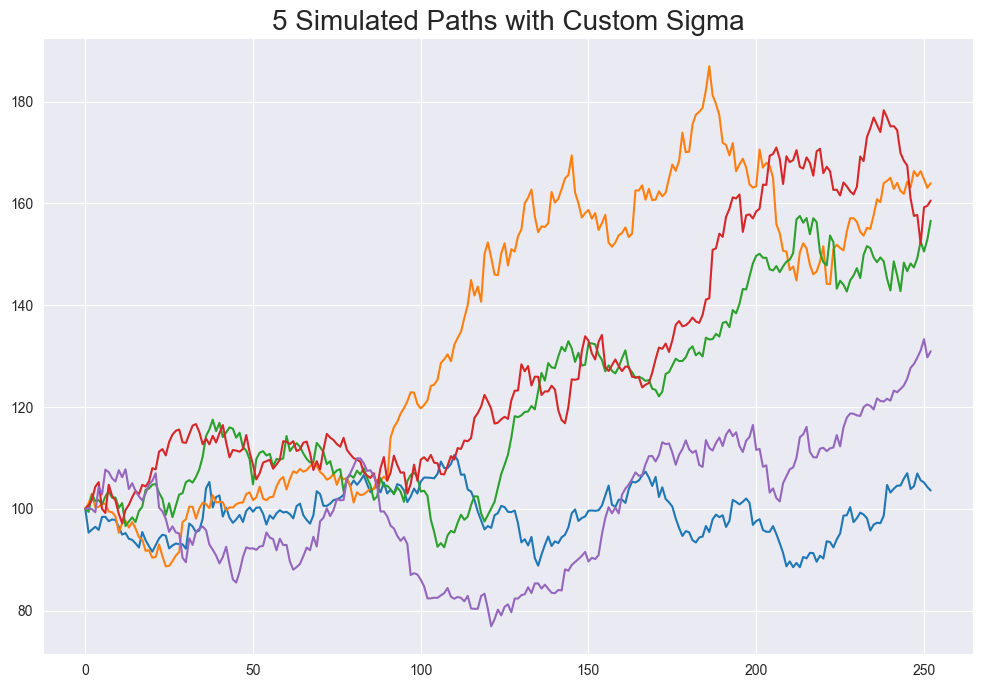

In [25]:
#5 Simulated paths of daily steps over 1-year period and plot

S0 = 100
t = 1
r = 0.039
mu = 0.275
n_paths = 5
n_steps = 252


simulated_paths = stock_path_custom_sigma(S0, t, r, mu, n_paths, n_steps)


plt.figure(figsize = (12,8))

for path in simulated_paths:
    plt.plot(path)
    
plt.title(f'{n_paths} Simulated Paths with Custom Sigma', size = 20)


plt.show()